# 🌐 Global News Analyzer Report

**Nom :** Djellouli Zakaria  
**ID :** 300150433  
**Cours :** INF1102 - Programmation de systèmes  
**Collège :** Collège Boréal


## 🎯 Objectif
Analyser des titres et afficher les mots les plus fréquents.

In [1]:
# 📥 Lecture DIRECTE du fichier log

titles = []

with open("data/sample.log", "r") as f:
    for line in f:
        titles.append(line.strip())

print("Nombre de titres :", len(titles))
print(titles[:5])

Nombre de titres : 20
['2026-04-15 02:10:05 | BBC News', '2026-04-15 02:10:06 | <![CDATA[Trump hints Iran talks could resume this week as US port blockade continues]]>', '2026-04-15 02:10:06 | <![CDATA[UK faces biggest hit to growth from Iran war of major economies, IMF says]]>', '2026-04-15 02:10:06 | <![CDATA[Help to Buy mostly helped high earners, IFS says]]>', '2026-04-15 02:10:06 | <![CDATA[King not meeting Epstein survivors, but state visit could help ease US-UK tensions]]>']


In [2]:
# 🔤 Analyse des mots (PRO)
import re
from collections import Counter

words = []

for t in titles:
    t = re.sub(r'[^a-zA-Z ]', ' ', t)
    parts = t.lower().split()
    words.extend(parts)

stop_words = {
    "the","and","for","with","from","this","that","have","will",
    "after","about","their","they","been","said","more","than",
    "into","over","when","were","news","bbc"
}

words = [w for w in words if w not in stop_words and len(w) > 3]

top = Counter(words).most_common(10)

print("Top words:", top)

Top words: [('cdata', 19), ('iran', 3), ('says', 3), ('talks', 2), ('could', 2), ('help', 2), ('strait', 2), ('hormuz', 2), ('peace', 2), ('trump', 1)]


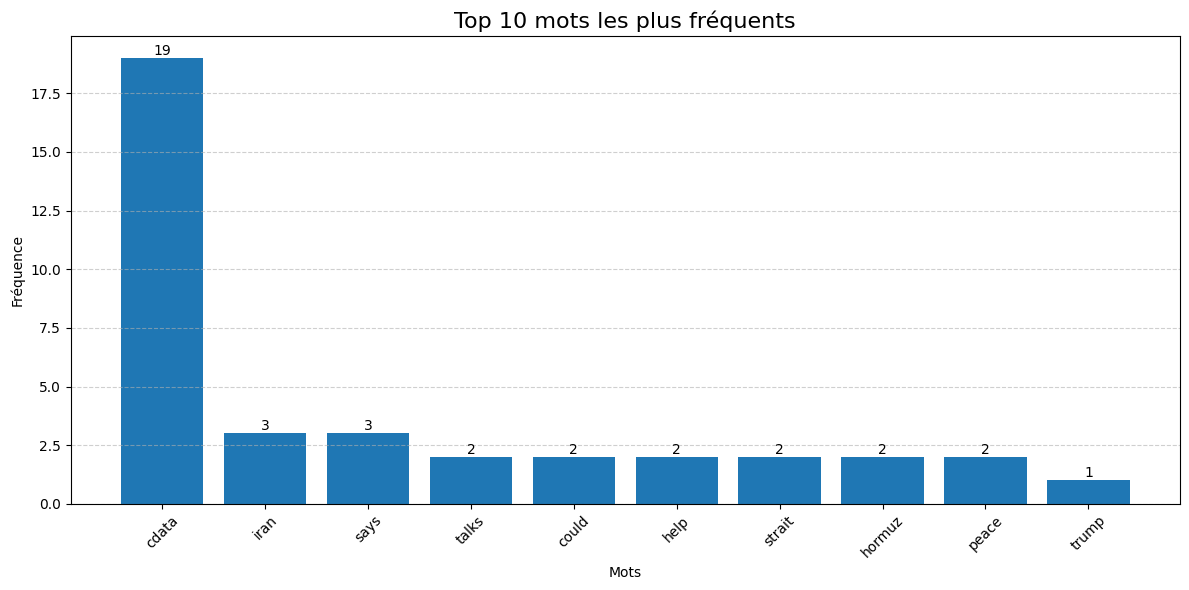

In [3]:
# 📊 Graphique FINAL (BEAU)
import matplotlib.pyplot as plt

if top:
    labels = [w for w, c in top]
    values = [c for w, c in top]

    plt.figure(figsize=(12,6))
    bars = plt.bar(labels, values)

    plt.title("Top 10 mots les plus fréquents", fontsize=16)
    plt.xlabel("Mots")
    plt.ylabel("Fréquence")
    plt.xticks(rotation=45)

    for bar in bars:
        y = bar.get_height()
        plt.text(bar.get_x()+bar.get_width()/2, y, int(y),
                 ha='center', va='bottom')

    plt.grid(axis='y', linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()
else:
    print("Aucune donnée")